# Load required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Epilepsy Dataset 

# Load Data

In [2]:
epilepsy = pd.read_csv('./Datasets/epilepsyOriginal.csv', sep= ',', decimal= '.', on_bad_lines = 'error', skip_blank_lines=False)

# Check if data loaded matches source 

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
epilepsy.head() 

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,Seizure Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,Jerky Movements,Postictal Confusion,Blank Stare Episodes,Eye Rolling,Stress or Anxiety Before Episode,Lack of Sleep Before Episode,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
0,15,Male,48.3,168.2,On Medication,Yes,Yes,Normal,1,60,Tonic-Clonic,No,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,Yes,Generalized
1,4,Female,56.0,174.5,On Medication,No,Yes,Abnormal,1,30,Generalized,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,No,No,Generalized
2,36,Female,44.8,156.2,On Medication,No,Yes,Abnormal,3,30,Tonic-Clonic,Yes,No,Yes,Yes,No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,No,No,Generalized
3,32,Female,70.4,180.4,Not on Medication,No,Yes,Not Done,0,60,Focal,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,Focal
4,29,Male,54.5,161.7,On Medication,No,Yes,Not Done,1,60,Tonic-Clonic,No,Yes,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,Yes,No,Yes,No,No,No,Generalized


In [5]:
epilepsy.tail()

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,Seizure Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,Jerky Movements,Postictal Confusion,Blank Stare Episodes,Eye Rolling,Stress or Anxiety Before Episode,Lack of Sleep Before Episode,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
719,18,Male,62.8,168.5,On Medication,No,Yes,Abnormal,1,60,Tonic-Clonic,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,No,No,No,No,No,No,Generalized
720,36,Female,69.2,168.3,On Medication,No,Yes,Abnormal,3,30,Generalized,Yes,No,No,No,Yes,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No,No,No,Generalized
721,54,Female,73.9,168.0,On Medication,No,Yes,Normal,2,90,Focal,Yes,Yes,No,Yes,Yes,No,No,Yes,No,Yes,No,No,No,Yes,No,No,No,No,Focal
722,44,Female,55.1,171.7,Not on Medication,No,Yes,Not Done,0,60,Focal,No,Yes,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,No,Yes,No,No,No,No,Focal
723,65,Female,50.9,169.4,On Medication,No,Yes,Abnormal,10,120,Focal,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,No,No,No,No,Focal


The number of rows and columns matches csv file. 

In [6]:
pd.reset_option('display.max_columns')

In [7]:
epilepsy.loc[epilepsy['Epilepsy Type'] == 'Generalized','Epilepsy Type'] = 'Generalised'

In [8]:
epilepsy.tail()

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,...,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
719,18,Male,62.8,168.5,On Medication,No,Yes,Abnormal,1,60,...,Yes,No,Yes,No,No,No,No,No,No,Generalised
720,36,Female,69.2,168.3,On Medication,No,Yes,Abnormal,3,30,...,Yes,No,No,No,No,No,No,No,No,Generalised
721,54,Female,73.9,168.0,On Medication,No,Yes,Normal,2,90,...,Yes,No,No,No,Yes,No,No,No,No,Focal
722,44,Female,55.1,171.7,Not on Medication,No,Yes,Not Done,0,60,...,Yes,No,No,No,Yes,No,No,No,No,Focal
723,65,Female,50.9,169.4,On Medication,No,Yes,Abnormal,10,120,...,No,Yes,Yes,No,Yes,No,No,No,No,Focal


# Data Cleaning

## Duplicated Rows

using .duplicated function to check duplicated rows and there are none. 

In [9]:
duplicate_mask = epilepsy.duplicated()
print("No. of duplicated rows:",duplicate_mask.sum())

No. of duplicated rows: 0


## Check data types
Using .info method we can check the data types in this dataset and its corresponding count. This dataset consists of 25 string/text, 2 integer, and 2 float variables.

In [10]:
epilepsy.info()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                724 non-null    int64  
 1   Gender                             724 non-null    str    
 2   Weight                             724 non-null    float64
 3   Height                             724 non-null    float64
 4   Medication Status                  724 non-null    str    
 5   Alcohol or Drug Use                724 non-null    str    
 6   EEG Abnormality Detected           724 non-null    str    
 7   MRI/CT Scan Result                 724 non-null    str    
 8   Seizure Frequency                  724 non-null    int64  
 9   Seizure Duration                   724 non-null    int64  
 10  Seizure Type                       724 non-null    str    
 11  Aura Before Seizure                724 non-null    str    
 12  Loss 

## String Data Type / Categorical Data

### Remove leading/trailing whitespace on variables with String data type 

Using the column names, we can check its type using .dtypes. If it is a string, we can remove any leading or trailing whitespaces.

In [11]:
# get column names 
col_names_all = epilepsy.columns.tolist()

for col_name in col_names_all:
    if(epilepsy[col_name].dtypes == 'string'):
        epilepsy[col_name] = epilepsy[col_name].str.strip()

### Correcting "Data Entry Mistakes" 

We can use value_counts to see the unique values and its corresponding count. 

In [12]:
for colname in col_names_all: 
    if epilepsy[colname].dtypes == 'string': 
        print(epilepsy[colname].value_counts().sort_index())
        print("-"*100)

Gender
Female    321
Male      390
Other      13
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Medication Status
Not on Medication    186
On Medication        538
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Alcohol or Drug Use
No     633
Yes     91
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
EEG Abnormality Detected
No      89
Yes    635
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
MRI/CT Scan Result
Abnormal    270
Normal      338
Not Done    116
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Seizure Type
Absence          20
Focal           261
Generalized     284
Tonic-Clonic    159

By observing the values above, there are no abnormal values for variables with string datatype. 

### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are no NULL values.

In [13]:
# columns with NULL/empty values for STRING data type
string_df = epilepsy.select_dtypes('string')
string_df.isnull().sum()

Gender                               0
Medication Status                    0
Alcohol or Drug Use                  0
EEG Abnormality Detected             0
MRI/CT Scan Result                   0
Seizure Type                         0
Aura Before Seizure                  0
Loss of Consciousness                0
Muscle Stiffness                     0
Jerky Movements                      0
Postictal Confusion                  0
Blank Stare Episodes                 0
Eye Rolling                          0
Stress or Anxiety Before Episode     0
Lack of Sleep Before Episode         0
Flashing Lights Sensitivity          0
Loud Sound Sensitivity               0
Missed Medication                    0
Family History of Epilepsy           0
Head Injury History                  0
Brain Tumor                          0
History of Stroke                    0
Genetic Disorder                     0
Developmental Delay (in Children)    0
Epilepsy Type                        0
dtype: int64

## Integer/Float/Quantitative Data

### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are no NULL values.

In [14]:
# columns with NULL/empty values for STRING data type
string_df = epilepsy.select_dtypes(['integer','float'])
string_df.isnull().sum()

Age                  0
Weight               0
Height               0
Seizure Frequency    0
Seizure Duration     0
dtype: int64

### Impossible values

In [15]:
quantitative_cols = epilepsy.select_dtypes(['integer','float']).columns.to_list()

#### Box plot to check for outliers

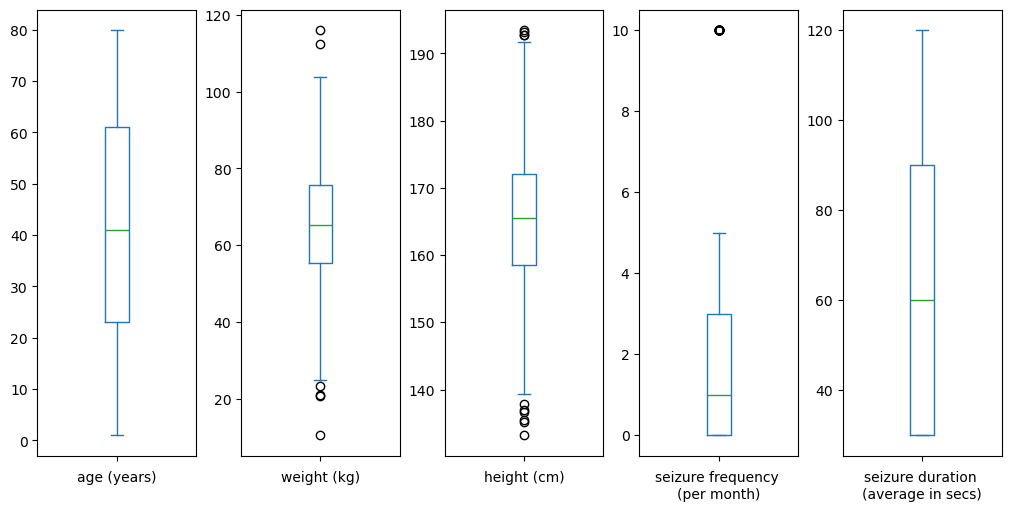

In [16]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 5)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    epilepsy[col].plot(kind = 'box', ax = ax)

    if(col.lower() == 'weight'): 
        col = col.lower() + ' (kg)'
    elif(col.lower() == 'height'): 
        col = col.lower() + ' (cm)'
    elif(col.lower() == 'seizure frequency'): 
        col = col.lower() + ' \n(per month)'
    elif(col.lower() == 'seizure duration'): 
        col = col.lower() + ' \n(average in secs)'
    elif(col.lower() == 'age'): 
        col = col.lower() + ' (years)'
        
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_xticklabels('')

From the boxplots above, we can observe that there are some outliers in variables weight, height, and seizure. These outliers will be investigated using descriptive statistics and scatter plots. The statistics plot can be found below this cell. 

#### Statistics

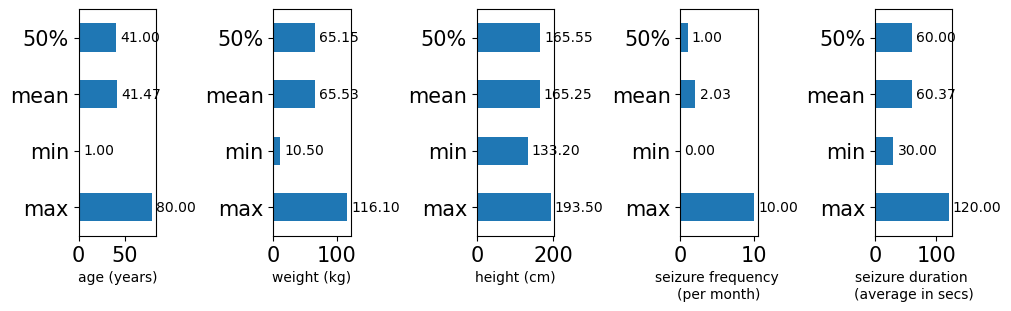

In [17]:
fig = plt.figure(figsize=(10, 3), constrained_layout=True)
axs = fig.subplots(1, 5)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    
    summary = epilepsy[col].describe()[['max', 'min','mean', '50%']]
    bars = summary.plot(kind='barh', ax=ax)

    # Add labels at the end of each horizontal bar
    ax.bar_label(bars.containers[0], labels=[f'{v:.2f}' for v in summary.values], padding=3)

    if(col.lower() == 'weight'): 
        col = col.lower() + ' (kg)'
    elif(col.lower() == 'height'): 
        col = col.lower() + ' (cm)'
    elif(col.lower() == 'seizure frequency'): 
        col = col.lower() + ' \n(per month)'
    elif(col.lower() == 'seizure duration'): 
        col = col.lower() + ' \n(average in secs)'
    elif(col.lower() == 'age'): 
        col = col.lower() + ' (years)'
        
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize =15)

The statistics tells us that the minimum age is 1 year old. By looking at the Weight vs Age and Height vs Age scatter plots below, age 1 has corresponding weights heavier than 20kg and heights taller than 150cm which is physically impossible. This is indicated using the red lines in the plots.

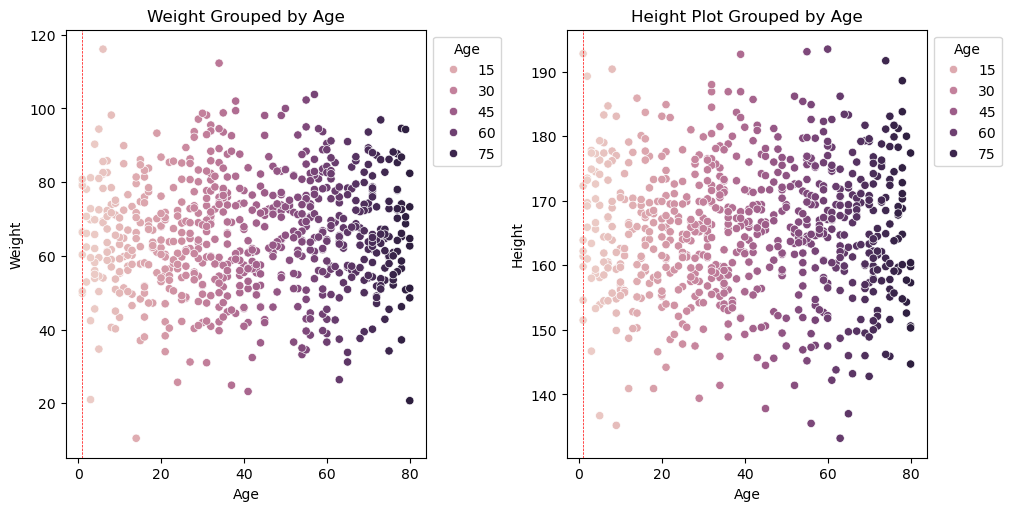

In [18]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 2)

# scatter plot for Weight vs Age
sns.scatterplot(data=epilepsy, x="Age", y="Weight", hue="Age", ax=axs[0])

axs[0].set_title("Weight Grouped by Age")

axs[0].axvline(x=1, color="red", linestyle="--", linewidth=0.5)

sns.move_legend(axs[0], loc="upper left", bbox_to_anchor=(1, 1))

# Scatter plot for Height vs Age
ax = sns.scatterplot(data=epilepsy, x="Age", y="Height", hue="Age", ax=axs[1])

axs[1].set_title("Height Plot Grouped by Age")

axs[1].axvline(x=1, color="red", linestyle="--", linewidth=0.5)

sns.move_legend(axs[1], loc="upper left", bbox_to_anchor=(1, 1))

As epilepsy is triggered by different causes at different age, a set of predefined values are used to check for Biologically Implausible Values(BVI). This values are found using Growth Charts by World Health Orgaisation (WHO) found on The Royoal Children's Hospital Melbourne Website[1]. This is split into different age groups and in each age group, different ranges of weight and height is considered for ages from 0 to 20. Extreme values are used for grown adults aged over 20. If their weight and height fall out of the range for his/her age, it is considered a BVI.

- [1] https://www.rch.org.au/childgrowth/About_child_growth/Growth_charts/

In [19]:
def clean_weight_height_data(df):
    # Copy of original dataset to work on
    df_copy = df.copy()

    # Calculate Body Mass Index (BMI)
    # BMI = weight (kg) / (height (m))^2
    height_meters = df_copy["Height"] / 100.0
    df_copy["bmi"] = df_copy["Weight"] / (height_meters**2)

    # 2. Set (Biologically Implausible Values)
    # Age 0 to 2, bmi not included as it isn't appropriate
    age_0_1 = df_copy["Age"] <= 1
    age_0_1 = age_0_1 & (
        (df_copy["Weight"] > 14.5)
        | (df_copy["Weight"] < 2.5)  
        | (df_copy["Height"] > 94)
        | (df_copy["Height"] < 45)  
    )

    # Age 2 to 5, 
    age_2_5 = (df_copy["Age"] >=2) & (df_copy["Age"] <= 5)
    age_2_5= age_2_5 & (
        (df_copy["Weight"] > 25)
        | (df_copy["Weight"] < 10)  
        | (df_copy["Height"] > 117)
        | (df_copy["Height"] < 79)
        | (df_copy["bmi"] > 18.5)
        | (df_copy["bmi"] < 13)
    )

    #  Age 6 to 10, bmi included 
    age_6_10 = (df_copy["Age"] >= 6) & (df_copy["Age"] <= 10) 
    age_6_10 = age_6_10 & (
        (df_copy["Weight"] > 50)
        | (df_copy["Weight"] < 15)
        | (df_copy["Height"] > 150)
        | (df_copy["Height"] < 90)
        | (df_copy["bmi"] > 23.5)
        | (df_copy["bmi"] < 13.5)
    )

    # Age 10 to 15, bmi included 
    age_11_15 = (df_copy["Age"] >= 11) & (df_copy["Age"] <= 15) 
    age_11_15 = age_11_15 & (
        (df_copy["Weight"] > 85)
        | (df_copy["Weight"] < 25)
        | (df_copy["Height"] > 185)
        | (df_copy["Height"] < 125)
        | (df_copy["bmi"] > 29)
        | (df_copy["bmi"] < 14)
    )

    # Age 10 to 15, bmi included 
    age_16_20 = (df_copy["Age"] >= 16) & (df_copy["Age"] <= 20) 
    age_16_20 = age_16_20 & (
        (df_copy["Weight"] > 100)
        | (df_copy["Weight"] < 45)
        | (df_copy["Height"] > 190)
        | (df_copy["Height"] < 155)
        | (df_copy["bmi"] > 32.5)
        | (df_copy["bmi"] < 17)
    )

    # adults: Age >20+
    adult_mask = df_copy["Age"] > 20
    adult_mask = adult_mask & (
        (df_copy["Weight"] > 400)
        | (df_copy["Weight"] < 25)
        | (df_copy["Height"] > 200)
        | (df_copy["Height"] < 100)
        | (df_copy["bmi"] > 204)
        | (df_copy["bmi"] < 10)  
    )
    
    # full mask 
    impossible_combinations_mask = age_0_1 | age_2_5 | age_6_10 | age_11_15 | age_16_20 | adult_mask

    # filter data with full mask 
    df_cleaned = df_copy[~impossible_combinations_mask].reset_index(drop=True)

    # Print data audit metrics
    print(f"Original observations: {len(df)}")
    print(f"Removed observations: {impossible_combinations_mask.sum()}")
    print(f"Cleaned observations: {len(df_cleaned)}")
    print(f"Percentage removed: {round((impossible_combinations_mask.sum()/len(df))*100,3)}%")

    return df_cleaned
    # return None

# Run the cleaner
epilepsy_clean = clean_weight_height_data(epilepsy)
epilepsy_clean = epilepsy_clean.drop("bmi", axis = 1)

Original observations: 724
Removed observations: 103
Cleaned observations: 621
Percentage removed: 14.227%


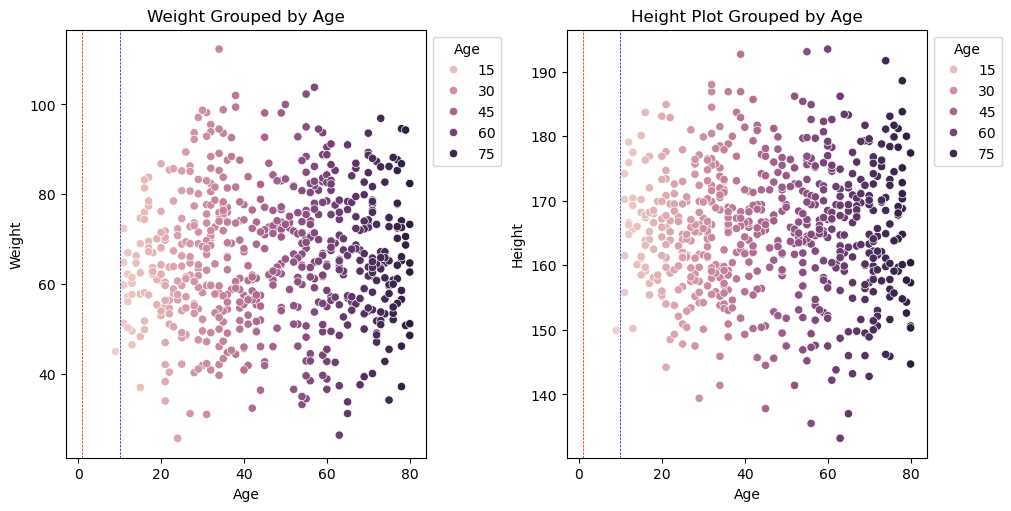

In [20]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 2)

current = epilepsy_clean

sns.scatterplot(data=current, x="Age", y="Weight", hue="Age", ax=axs[0])
# sns.move_legend(ax,loc="lower center", bbox_to_anchor=(1, 0.5, 0, 1))

axs[0].set_title("Weight Grouped by Age")

axs[0].axvline(x=1, color="red", linestyle="--", linewidth=0.5)
axs[0].axvline(x=10, color="blue", linestyle="--", linewidth=0.5)

sns.move_legend(axs[0], loc="upper left", bbox_to_anchor=(1, 1))

ax = sns.scatterplot(data=current, x="Age", y="Height", hue="Age", ax=axs[1])
# sns.move_legend(ax,loc="lower center", bbox_to_anchor=(1, 0.5, 0, 1))

axs[1].set_title("Height Plot Grouped by Age")

axs[1].axvline(x=1, color="red", linestyle="--", linewidth=0.5)
axs[1].axvline(x=10, color="blue", linestyle="--", linewidth=0.5)

sns.move_legend(axs[1], loc="upper left", bbox_to_anchor=(1, 1))

Figures above shows the data after removing Biologically Implausible Values. The values around red vertical line which is plotted at age = 1 and blue line is plotted at age = 10. Most of the data from ages 1 to 10 were removed. This shows that there are a lot of errors during data collection. The downside is 14% of the data is removed which is not ideal. However, epilepsy can happen to all ages and rooting out these impossible combinations is crucial for more representative data. However, epilepsy can happen to all ages and rooting out these impossible combinations help ensure data used reflects real world data accurately.

After removing those impossible values, there are still some outlier which can be found in the plot below. The are still outliers beyond the upper fence of variable weight and seizure frequency. For variable height, there are values beyond the upper and lower fence. These outliers are safe to be considered valid as a person could weight more than 100kg and grow taller than 190cm. There is a big range of ages and younger patients are likely to be below 140cm. For the seizure variable, it depends on indivuals and what health conditions they have. Having 10 per month is possible [2]. 

- [2] https://www.who.int/news-room/fact-sheets/detail/epilepsy

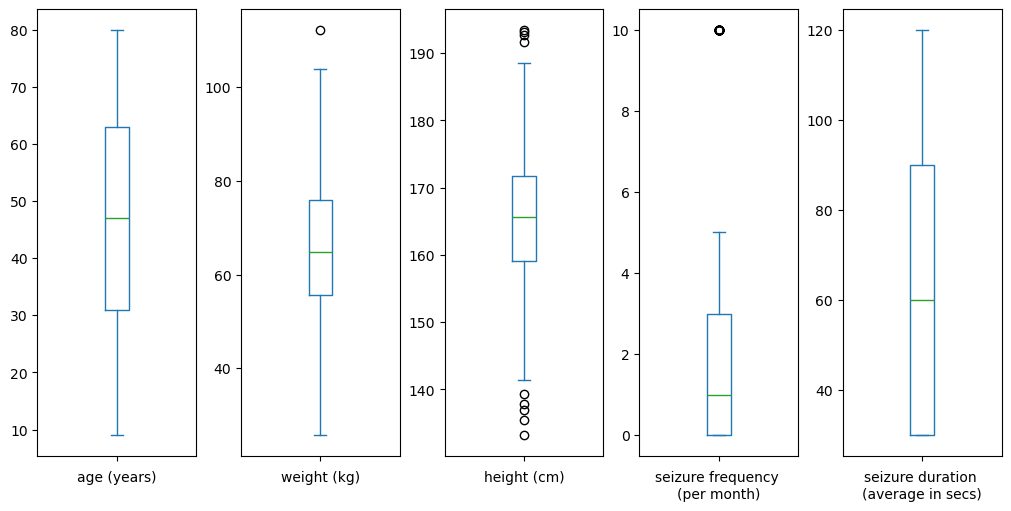

In [21]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 5)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    epilepsy_clean[col].plot(kind = 'box', ax = ax)

    if(col.lower() == 'weight'): 
        col = col.lower() + ' (kg)'
    elif(col.lower() == 'height'): 
        col = col.lower() + ' (cm)'
    elif(col.lower() == 'seizure frequency'): 
        col = col.lower() + ' \n(per month)'
    elif(col.lower() == 'seizure duration'): 
        col = col.lower() + ' \n(average in secs)'
    elif(col.lower() == 'age'): 
        col = col.lower() + ' (years)'
        
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_xticklabels('')

# Save data

We have now dealt with all categorical and numerical data. We can now save it as a clean csv.

In [22]:
epilepsy_clean.to_csv("./Datasets/epilepsyCleaned.csv", index= False)

# Data Enconding

## Encode categorical values

As this data will be fitted into a Decision Tree and Logistic Regression Model, evaluation method such as cross validation will be performed to conduct my model parameter tuning. Method cross_val_score[1] by sci-kit learn only accepts numerical data. There are a lot of qualitative data in this dataset. Hence, they are one hot encoded using pandas' get_dummies method[2]

- [1] https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- [2] https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

In [23]:
encoded_epilepsy = pd.get_dummies(
    epilepsy_clean,
    columns=['Gender', 'Medication Status', 'Alcohol or Drug Use', 'EEG Abnormality Detected', 'MRI/CT Scan Result', 
             'Seizure Type', 'Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness', 'Jerky Movements', 
             'Postictal Confusion', 'Blank Stare Episodes', 'Eye Rolling', 'Stress or Anxiety Before Episode', 
             'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity', 'Loud Sound Sensitivity', 'Missed Medication',
             'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor', 'History of Stroke', 'Genetic Disorder',
             'Developmental Delay (in Children)'],
    drop_first=False
)

In [24]:
pd.set_option('display.max_columns', None)

In [25]:
encoded_epilepsy.head()

,Age,Weight,Height,Seizure Frequency,Seizure Duration,Epilepsy Type,Gender_Female,Gender_Male,Gender_Other,Medication Status_Not on Medication,Medication Status_On Medication,Alcohol or Drug Use_No,Alcohol or Drug Use_Yes,EEG Abnormality Detected_No,EEG Abnormality Detected_Yes,MRI/CT Scan Result_Abnormal,MRI/CT Scan Result_Normal,MRI/CT Scan Result_Not Done,Seizure Type_Absence,Seizure Type_Focal,Seizure Type_Generalized,Seizure Type_Tonic-Clonic,Aura Before Seizure_No,Aura Before Seizure_Yes,Loss of Consciousness_No,Loss of Consciousness_Yes,Muscle Stiffness_No,Muscle Stiffness_Yes,Jerky Movements_No,Jerky Movements_Yes,Postictal Confusion_No,Postictal Confusion_Yes,Blank Stare Episodes_No,Blank Stare Episodes_Yes,Eye Rolling_No,Eye Rolling_Yes,Stress or Anxiety Before Episode_No,Stress or Anxiety Before Episode_Yes,Lack of Sleep Before Episode_No,Lack of Sleep Before Episode_Yes,Flashing Lights Sensitivity_No,Flashing Lights Sensitivity_Yes,Loud Sound Sensitivity_No,Loud Sound Sensitivity_Yes,Missed Medication_No,Missed Medication_Yes,Family History of Epilepsy_No,Family History of Epilepsy_Yes,Head Injury History_No,Head Injury History_Yes,Brain Tumor_No,Brain Tumor_Yes,History of Stroke_No,History of Stroke_Yes,Genetic Disorder_No,Genetic Disorder_Yes,Developmental Delay (in Children)_No,Developmental Delay (in Children)_Yes
0,15,48.3,168.2,1,60,Generalised,False,True,False,False,True,False,True,False,True,False,True,False,False,False,False,True,True,False,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,False,True
1,36,44.8,156.2,3,30,Generalised,True,False,False,False,True,True,False,False,True,True,False,False,False,False,False,True,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,True,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False
2,32,70.4,180.4,0,60,Focal,True,False,False,True,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False
3,29,54.5,161.7,1,60,Generalised,False,True,False,False,True,True,False,False,True,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True,True,False,True,False,False,True,True,False,False,True,True,False,False,True,True,False,True,False,True,False
4,18,62.1,168.0,1,30,Generalised,False,True,False,False,True,True,False,False,True,True,False,False,False,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,True,False,True,False,True,True,False,True,False,False,True,True,False,True,False,True,False,True,False,True,False


In [26]:
pd.reset_option('display.max_columns')

In [27]:
encoded_epilepsy.shape

(621, 58)

The cell above shows the one hot encoded data of epilepsy. For example, variable Gender is now split into three columns, Gender_Female, Gender_Male, and Gender_Other. The cell above with the shape function also shows the dataset now has 621 rows and 58 columns. We can now save it in a new csv file. 

In [28]:
encoded_epilepsy.to_csv("./Datasets/OneHotEpilepsyCleaned.csv", index= False)

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Dementia Data Set

# Load Dataset 

In [29]:
dementia = pd.read_csv('./Datasets/oasis_longitudinal_demographics.csv', sep= ',', decimal= '.', on_bad_lines = 'error', skip_blank_lines=False)

# Check if data loaded matches source 

In [30]:
dementia.head() 

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [31]:
dementia.tail() 

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323
372,OAS2_0186,OAS2_0186_MR3,Nondemented,3,1608,F,R,65,13,2.0,30.0,0.0,1333,0.801,1.317


# Data Cleaning

## Duplicated Rows

using .duplicated function to check duplicated rows and there are none. 

In [32]:
duplicate_mask = dementia.duplicated()
print("No. of duplicated rows:",duplicate_mask.sum())

No. of duplicated rows: 0


## Check data types
using dtypes and value_counts(), we can check the data types in this dataset and its corresponding count. This dataset consists of 5 string/text, 5 integer, and 5 float variables.

In [33]:
dementia.info()

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    str    
 1   MRI ID      373 non-null    str    
 2   Group       373 non-null    str    
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    str    
 6   Hand        373 non-null    str    
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), str(5)
memory usage: 43.8 KB


In [34]:
dementia.dtypes.value_counts()

str        5
int64      5
float64    5
Name: count, dtype: int64

## String Data Type / Categorical Data

### Remove leading/trailing whitespace on variables with String data type 

Using the column names, we can check its type using .dtypes. If it is a string, we can remove any leading or trailing whitespaces.

In [35]:
# get column names 
col_names_all = dementia.columns.tolist()

for col_name in col_names_all:
    if(dementia[col_name].dtypes == 'string'):
        dementia[col_name] = dementia[col_name].str.strip()

### Correcting "Data Entry Mistakes" 

Using .info method we can check the data types in this dataset and its corresponding count. Subject ID and MRI ID are excluded as each patient and every MRI scan session will have an uniqueID. From the output below, we can observe that there are no incorrect or entry mistakes.

In [36]:
for colname in col_names_all: 
        if dementia[colname].dtypes == 'string' and colname not in ['Subject ID', 'MRI ID']: 
            print(dementia[colname].value_counts().sort_index())
            print("-"*100)

Group
Converted       37
Demented       146
Nondemented    190
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
M/F
F    213
M    160
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Hand
R    373
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are no NULL values.

In [37]:
# columns with NULL/empty values for STRING data type
string_df = dementia.select_dtypes('string')
string_df.isnull().sum()

Subject ID    0
MRI ID        0
Group         0
M/F           0
Hand          0
dtype: int64

## Integer/Float/Quantitative Data

### Check for NULL/empty values

Using .isnull() and .sum(), we can see there are 19 NULL values in variable SES and 2 in MMSE. 

In [38]:
# columns with NULL/empty values for STRING data type
string_df = dementia.select_dtypes(['integer','float'])
string_df.isnull().sum()

Visit        0
MR Delay     0
Age          0
EDUC         0
SES         19
MMSE         2
CDR          0
eTIV         0
nWBV         0
ASF          0
dtype: int64

### Remove NULL value 
Since 19 is a relatively small amount of data, they were removed. 

In [39]:
dementia = dementia[~dementia['SES'].isnull()]

After removing the 19 NULLs in SES, the 2 NULLs in MMSE were removed too. The output below shows there are not NULL values left.

In [40]:
string_df = dementia.select_dtypes(['integer','float'])
string_df.isnull().sum()

Visit       0
MR Delay    0
Age         0
EDUC        0
SES         0
MMSE        0
CDR         0
eTIV        0
nWBV        0
ASF         0
dtype: int64

### Impossible values

In [41]:
quantitative_cols = dementia.select_dtypes(['integer','float']).columns.to_list()

#### Box plot to check for outliers

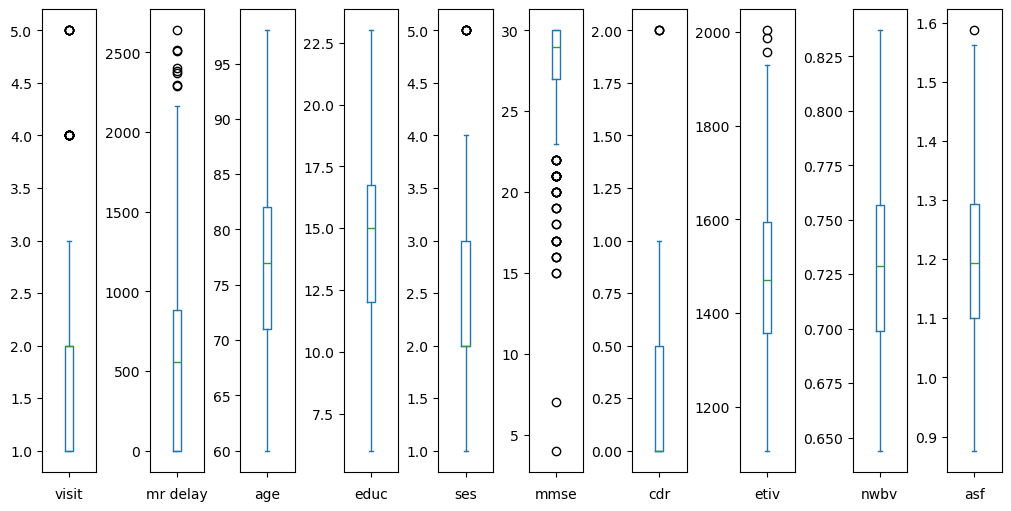

In [42]:
fig = plt.figure(figsize=(10, 5), constrained_layout=True)
axs = fig.subplots(1, 10)

for i, col in enumerate(quantitative_cols): 
    ax = axs[i]
    dementia[col].plot(kind = 'box', ax = ax)
    ax.set_xlabel(col.lower(), fontsize = 10)
    ax.set_xticklabels('')

From the boxplots above, variables visit, mr delay, ses, mmse, cdr, etiv, and asf have outliers. None of these outliers will be removed and the reseaon will be discussed here. 
- Visit - visit number. the data is collected from a longitudinal collection approach where patients were scanned more than 1 visit and visits are separated by at least 1 year. Some patients will have more visits than others.
- MR Delay (days) - Days between the patient's visit and previous visit. Some patients have more days between visits than others.
- SES (1-5) - SES stands for socialeconomic status. This depends on the patient's background and some can be higher than others.
- mmse (points)- MMSE stands for minimental state examination. It is a scoring point system which ranges from 0 to 30. Patients are asked 20 questions that assesses their cognitive domains.[1]
- CDR - CRD stands for Clinical Dementia Rating. The ratings are 0 = no dementia, 0.5 = questionable, 1 = mild, 2 = moderate, 3 = severe. [2]
- etiv (cm^3)- eTIV stand for Estimated total intracranial volume and is measured in cm^3. Based off FreeSurfer [3] a software that measure the approximate cranial size from MRI scans, the valid ranges are from 1,100 to 1,300. Any values below 900 and beyond 2000 suggests outliers. The maximum values are within these range. 
- asf - ASF stands for Atlas scaling factor. It is the volume-scaling factor required to match patient to the atlas target. Atlas normalisation equates headsize and should be proportional to etiv [4]. Since etiv are valid, ASF should be.

Based off the information above, the outliers are within the limits of each variable's definition and therefore valid. They are kept in the dataset. 

- [1] https://www.sciencedirect.com/science/chapter/monograph/pii/B9780323778466000069
- [2] https://www.sciencedirect.com/science/article/pii/S1041610224056588
- [3] https://surfer.nmr.mgh.harvard.edu/fswiki/eTIV 
- [4] https://www.sciencedirect.com/science/article/pii/S1053811904003271


# Drop values

We have now cleaned the dementia dataset. Before moving on, there are a few variables that we can remove as they will not contribute to data modelling. The variables are 'Subject ID', 'MRI ID', 'MR Delay', and 'Hand'. These variables do not represent biological or clinical factors relevant to classifying dementia. For example, SubjectID and MRI ID might cause overfitting as the model might try to memorise some identical string. Number of visits and days between scans have no effect on someone getting dementia. Finally all tested patients are right handed. 

In [43]:
dementia = dementia.drop(columns=['Subject ID', 'MRI ID', 'MR Delay', 'Hand'])

In [44]:
dementia.head()

,Group,Visit,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
5,Nondemented,1,F,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,Nondemented,2,F,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,Nondemented,1,M,80,12,4.0,28.0,0.0,1689,0.712,1.039


# Save data

We have now dealt with all categorical and numerical data. We can now save it as a clean csv.

In [45]:
dementia.to_csv("./Datasets/dementiaCleaned.csv", index= False)

# Data Enconding

In [46]:
dementia.columns

Index(['Group', 'Visit', 'M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV',
       'nWBV', 'ASF'],
      dtype='str')

## Encode categorical values

Encode variables for models and evaluation methods that only accepts numerical data. 

In [47]:
encoded_dementia = pd.get_dummies(
    dementia,
    columns=['M/F'],
    drop_first=False
)

In [48]:
encoded_dementia.head()

,Group,Visit,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,M/F_F,M/F_M
0,Nondemented,1,87,14,2.0,27.0,0.0,1987,0.696,0.883,False,True
1,Nondemented,2,88,14,2.0,30.0,0.0,2004,0.681,0.876,False,True
5,Nondemented,1,88,18,3.0,28.0,0.0,1215,0.710,1.444,True,False
6,Nondemented,2,90,18,3.0,27.0,0.0,1200,0.718,1.462,True,False
7,Nondemented,1,80,12,4.0,28.0,0.0,1689,0.712,1.039,False,True


In [49]:
encoded_dementia.to_csv("./Datasets/OneHotDementiaCleaned.csv", index= False)